<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 36px 34px; box-shadow: 0 4px 18px rgba(44,62,80,0.08);">
<div style="width: 56px; height: 5px; background: #3498db; border-radius: 3px; margin-bottom: 16px;"></div>
<h2 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 20px 0; font-size: 1.8em; font-weight: 800; color: #2c3e50;">המרת הקבצים לפורמט אחיד</h2>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50; font-size: 1.05em;">כחלק מההכנה להרצת מנוע ה-OCR, נדרש להביא את הקבצים לפורמט אחיד המותאם לעיבוד ממוחשב. בסקריפט הבא נמיר אוטומטית את עמודי מסמכי ה-Word וה-PDF לתמונות JPG ברזולוציה גבוהה (300 DPI).</div>
</div>

In [1]:
import os
import pandas as pd
from docx2pdf import convert # This method requires Microsoft Word to be installed on the machine.
import pymupdf
import matplotlib.pyplot as plt

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Constants</div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 6px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">הגדרת קבועים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 16px 0; color: #5d6d7e;">ריכוז הנתיבים והפרמטרים במקום אחד, כדי שניתן יהיה לשנותם בלי לגעת בשאר הקוד:</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">נתיבי הנתונים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">תיקיית הקלט מכילה את המסמכים הגולמיים כפי שהתקבלו, ותיקיית הפלט מיועדת לתמונות שייווצרו בתהליך ההמרה.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">רזולוציית הפלט</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">נבחרה רזולוציה של 300 DPI, הנחשבת לסף המקובל לסריקת מסמכים לצורכי OCR. רזולוציה נמוכה יותר פוגעת בזיהוי התווים, וגבוהה יותר מכבידה על זמן העיבוד בלי שיפור משמעותי.</div>
</div>
</div>

In [2]:
# Consts
RAW_DATA_DIR = "./data"
CLEAN_DATA_DIR = "./dataset_images"

# 300 DPI (dots per inch) is the classic threshold
# where normal eyes at a standard viewing distance of 12 inches (30 cm)
# can no longer see individual ink dots.
OUTPUT_RESOLUTION = 300

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Data Loading</div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">טעינת הנתונים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">התא סורק באופן רקורסיבי את תיקיית הקלט על כל תת-התיקיות שלה, ואוסף עבור כל קובץ את שמו, סיומתו, נתיבו המלא וגודלו בבתים. התוצאה מרוכזת בטבלה אחת המשמשת בסיס לכל שלבי הבדיקה והסינון שבהמשך.</div>
</div>

In [3]:
file_records = []

for current_dir, _, filenames in os.walk(RAW_DATA_DIR):
    for filename in filenames:
        full_path = os.path.join(current_dir, filename)
        extension = os.path.splitext(filename)[1].lower()

        file_records.append({
            "filename": filename,
            "extension": extension,
            "path": full_path,
            "size_bytes": os.path.getsize(full_path),
        })

files_df = pd.DataFrame(file_records)
#display(files_df)
print(f"Total input files: {len(files_df)}")


Total input files: 51


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Data Discovery</div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">היכרות ראשונית עם הנתונים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">הצגת השורות הראשונות בטבלה, כדי לוודא שהסריקה אספה את הקבצים הצפויים ושהשדות נקראו כראוי לפני שממשיכים לניתוח.</div>
</div>

In [4]:
files_df.head()

,filename,extension,path,size_bytes
0,passport1.jpg,.jpg,./data\passports_images\passport1.jpg,378077
1,passport2.jpg,.jpg,./data\passports_images\passport2.jpg,379185
2,passport3.jpeg,.jpeg,./data\passports_images\passport3.jpeg,186763
3,passport_on_table.png,.png,./data\passports_images\passport_on_table.png,1820023
4,P_AU_A0091000_L1_B1_A1_D1.jpg,.jpg,./data\passports_images\with_photo\P_AU_A00910...,3659312


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">File Extension Distribution</div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">התפלגות סוגי הקבצים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">בחינת ההרכב של מאגר הקבצים לפי סיומת. ההתפלגות קובעת אילו מסלולי המרה נדרשים בפועל, ומאפשרת לזהות סוגי קבצים בלתי צפויים שיש לטפל בהם או להוציא מהמאגר.</div>
</div>

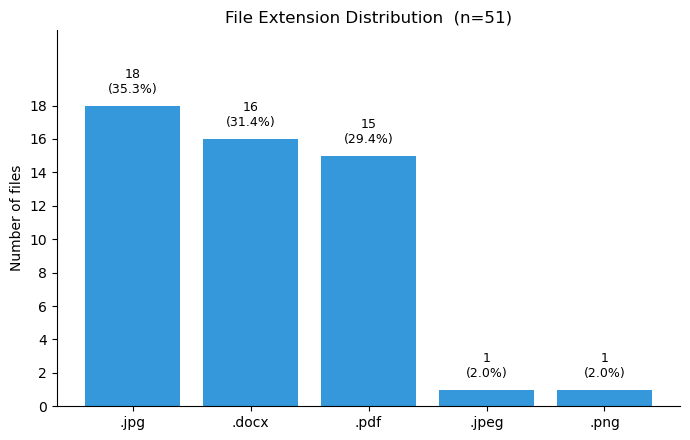

In [12]:
counts = files_df["extension"].value_counts()
total = counts.sum()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(counts.index, counts.values, color="#3498db")

for bar, value in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + total * 0.015,
        f"{value}\n({value / total:.1%})",
        ha="center",
        fontsize=9,
    )

ax.set_title(f"File Extension Distribution  (n={total})")
ax.set_ylabel("Number of files")
ax.set_ylim(0, counts.max() * 1.25)
ax.set_yticks(range(0, counts.max() + 2, 2))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">ממצאים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">המאגר מונה 51 קבצים בחמש סיומות. הסיומת השכיחה ביותר היא JPG (35.3%), אחריה DOCX (31.4%) ו-PDF (29.4%), ואילו JPEG ו-PNG מיוצגות בקובץ בודד כל אחת (2.0%).</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Data Filtering</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">בידוד המסמכים להמרה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">שלב ההמרה מיועד למסמכים בלבד, ולכן נבחרים מתוך המאגר רק הקבצים מסוג PDF, DOCX ו-DOC. יתר הקבצים אינם רלוונטיים לשלב זה. לבסוף מאותחל האינדקס כדי שהטבלה המסוננת תהיה ממוספרת ברצף.</div>
</div>

In [6]:
extensions_to_process = [".pdf", ".docx", ".doc"]

documents_df = (
    files_df[
        files_df["extension"].isin(extensions_to_process)
        & ~files_df["filename"].str.startswith(("~$", "~"))
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Documents to process: {len(documents_df)}")
print(f"Removed files: {(len(files_df) - len(documents_df))}")
print("Filtered document types numbers:")
print(documents_df["extension"].value_counts())

Documents to process: 31
Removed files: 20
Filtered document types numbers:
extension
.docx    16
.pdf     15
Name: count, dtype: int64


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">מסקנות</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מתוך 51 הקבצים במאגר, 31 הם מסמכים המיועדים להמרה  16 בפורמט DOCX ו-15 בפורמט PDF. יתר 20 הקבצים אינם רלוונטיים לשלב זה. לא נמצאו קובצי נעילה זמניים, ולכן הסינון בפועל התבסס על הסיומת בלבד.</div>
</div>

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Documents to Images Transformation</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">המרת מסמכים לתמונות</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 12px 0; line-height: 1.8; color: #2c3e50;">מנוע ה-OCR פועל על תמונות בלבד, ולכן כל מסמך מרונדר לסדרת תמונות JPG אחת לכל עמוד  ברזולוציה שהוגדרה קודם. שם כל תמונה נגזר משם המסמך המקורי בתוספת מספר העמוד, כדי לשמר את הקישור בין התמונה למקורה.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">מסמכי Word אינם מרונדרים ישירות אלא מומרים תחילה ל PDF זמני, ומשם ממשיכים באותו מסלול רינדור. כך שני סוגי המסמכים מתנקזים למימוש אחד, והקובץ הזמני נמחק בכל מקרה גם אם ההמרה נכשלה.</div>
</div>
</div>

In [7]:
def extract_pdf(pdf_path, original_path):
    base_name = os.path.splitext(os.path.basename(original_path))[0]

    extracted_images = []

    with pymupdf.open(pdf_path) as pdf_document:
        for page_num in range(len(pdf_document)):
            page = pdf_document.load_page(page_num)

            image_path = os.path.join(CLEAN_DATA_DIR, f"{base_name}_page_{page_num + 1}.jpg")

            page.get_pixmap(dpi=OUTPUT_RESOLUTION, alpha=False).save(image_path)

            extracted_images.append(image_path)

    return extracted_images


def extract_docx(docx_path):
    base_name = os.path.splitext(os.path.basename(docx_path))[0]

    tmp_pdf = os.path.join(CLEAN_DATA_DIR, f"{base_name}_tmp.pdf")

    try:
        convert(docx_path, tmp_pdf)
        return extract_pdf(tmp_pdf, docx_path)

    finally:
        if os.path.exists(tmp_pdf):
            os.remove(tmp_pdf)

In [8]:
# Create output folder
os.makedirs(CLEAN_DATA_DIR, exist_ok=True)

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Batch Conversion</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">הרצת ההמרה על כלל המסמכים</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0; line-height: 1.8; color: #2c3e50;">הפונקציות שהוגדרו לעיל מופעלות על 31 המסמכים, כשסיומת הקובץ קובעת באיזו מהן להשתמש. כל מסמך מעובד בנפרד ובאופן עצמאי, כך שכישלון בקובץ בודד מתועד עם הודעת השגיאה שלו ואינו עוצר את יתר העיבוד. עבור כל מסמך נרשמים בטבלה סטטוס ההמרה, מספר העמודים שרונדרו ונתיבי התמונות שנוצרו, ובסיום מוצג פילוח הסטטוסים.</div>
</div>

In [14]:
documents_df["status"] = "pending"
documents_df["page_count"] = 0
documents_df["output_images"] = None
documents_df["error"] = None

for index, row in documents_df.iterrows():
    source_path = row["path"]
    extension = row["extension"]

    print(
        f"[{index + 1}/{len(documents_df)}] "
        f"Processing: {source_path}"
    )

    try:
        if extension == ".pdf":
            output_images = extract_pdf(
                pdf_path=source_path,
                original_path=source_path
            )

        else:
            output_images = extract_docx(source_path)

        documents_df.at[index, "status"] = "success"
        documents_df.at[index, "page_count"] = len(output_images)
        documents_df.at[index, "output_images"] = output_images

    except Exception as error:
        documents_df.at[index, "status"] = "failed"
        documents_df.at[index, "error"] = str(error)

#display(documents_df)
print("\nProcessing complete.")
print(documents_df["status"].value_counts())

[1/31] Processing: ./data\pdf\PDF_Normal_Doc_1.pdf
[2/31] Processing: ./data\pdf\PDF_Normal_Doc_10.pdf
[3/31] Processing: ./data\pdf\PDF_Normal_Doc_2.pdf
[4/31] Processing: ./data\pdf\PDF_Normal_Doc_3.pdf
[5/31] Processing: ./data\pdf\PDF_Normal_Doc_4.pdf
[6/31] Processing: ./data\pdf\PDF_Normal_Doc_5.pdf
[7/31] Processing: ./data\pdf\PDF_Normal_Doc_6.pdf
[8/31] Processing: ./data\pdf\PDF_Normal_Doc_7.pdf
[9/31] Processing: ./data\pdf\PDF_Normal_Doc_8.pdf
[10/31] Processing: ./data\pdf\PDF_Normal_Doc_9.pdf
[11/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_11.pdf
[12/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_12.pdf
[13/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_13.pdf
[14/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_14.pdf
[15/31] Processing: ./data\pdf\edge_cases\PDF_Edge_Case_15.pdf
[16/31] Processing: ./data\word\Word_Normal_Doc_1.docx


  0%|          | 0/1 [00:00<?, ?it/s]

[17/31] Processing: ./data\word\Word_Normal_Doc_10.docx


  0%|          | 0/1 [00:00<?, ?it/s]

[18/31] Processing: ./data\word\Word_Normal_Doc_2.docx


...

[30/31] Processing: ./data\word\edge_cases\Word_Edge_Case_15.docx


  0%|          | 0/1 [00:00<?, ?it/s]

[31/31] Processing: ./data\word\edge_cases\Word_Edge_Case_16.docx


  0%|          | 0/1 [00:00<?, ?it/s]


Processing complete.
status
success    31
Name: count, dtype: int64


<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #ffffff; border: 1px solid #e1e8ed; border-radius: 12px; padding: 24px 26px; box-shadow: 0 2px 10px rgba(44,62,80,0.06);">
<div style="direction: ltr !important; text-align: left !important; font-family: inherit; font-size: 0.82em; font-weight: 700; letter-spacing: 1.5px; text-transform: uppercase; color: #7f9bb3; margin-bottom: 4px;">Transformation Summary</div>
<div style="width: 40px; height: 4px; background: #3498db; border-radius: 3px; margin-bottom: 12px;"></div>
<h3 style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 14px 0; font-size: 1.35em; font-weight: 700; color: #2c3e50;">סיכום חזותי של תהליך ההמרה</h3>
<div style="direction: rtl !important; text-align: right !important; font-family: inherit; margin: 0 0 16px 0; line-height: 1.8; color: #2c3e50;">מטרת התא היא ליצור לוח מחוונים בשישה גרפים, המאפשר להעריך את איכות ההמרה ואת היקף התוצרים לפני המעבר לשלב ה-OCR. לצורך כך נוצר עותק של טבלת המסמכים, שבו גודל הקובץ מומר למגה-בייט ומספר העמודים לערך מספרי.</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px; margin-bottom: 10px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">הצלחת התהליך והיקפו</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">גרף סטטוס ההמרה, גרף חלוקת המסמכים לפי סוג קובץ, וגרף כמות התמונות שנוצרה מכל סוג.</div>
</div>
<div style="direction: rtl !important; text-align: right !important; background: #f7fafc; border-right: 4px solid #3498db; border-radius: 8px; padding: 12px 16px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 6px;">מאפייני המסמכים והתוצרים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">גרף התפלגות מספר העמודים למסמך, גרף פיזור של גודל הקובץ המקורי מול מספר העמודים, וגרף המסמכים העשירים ביותר בעמודים.</div>
</div>
</div>

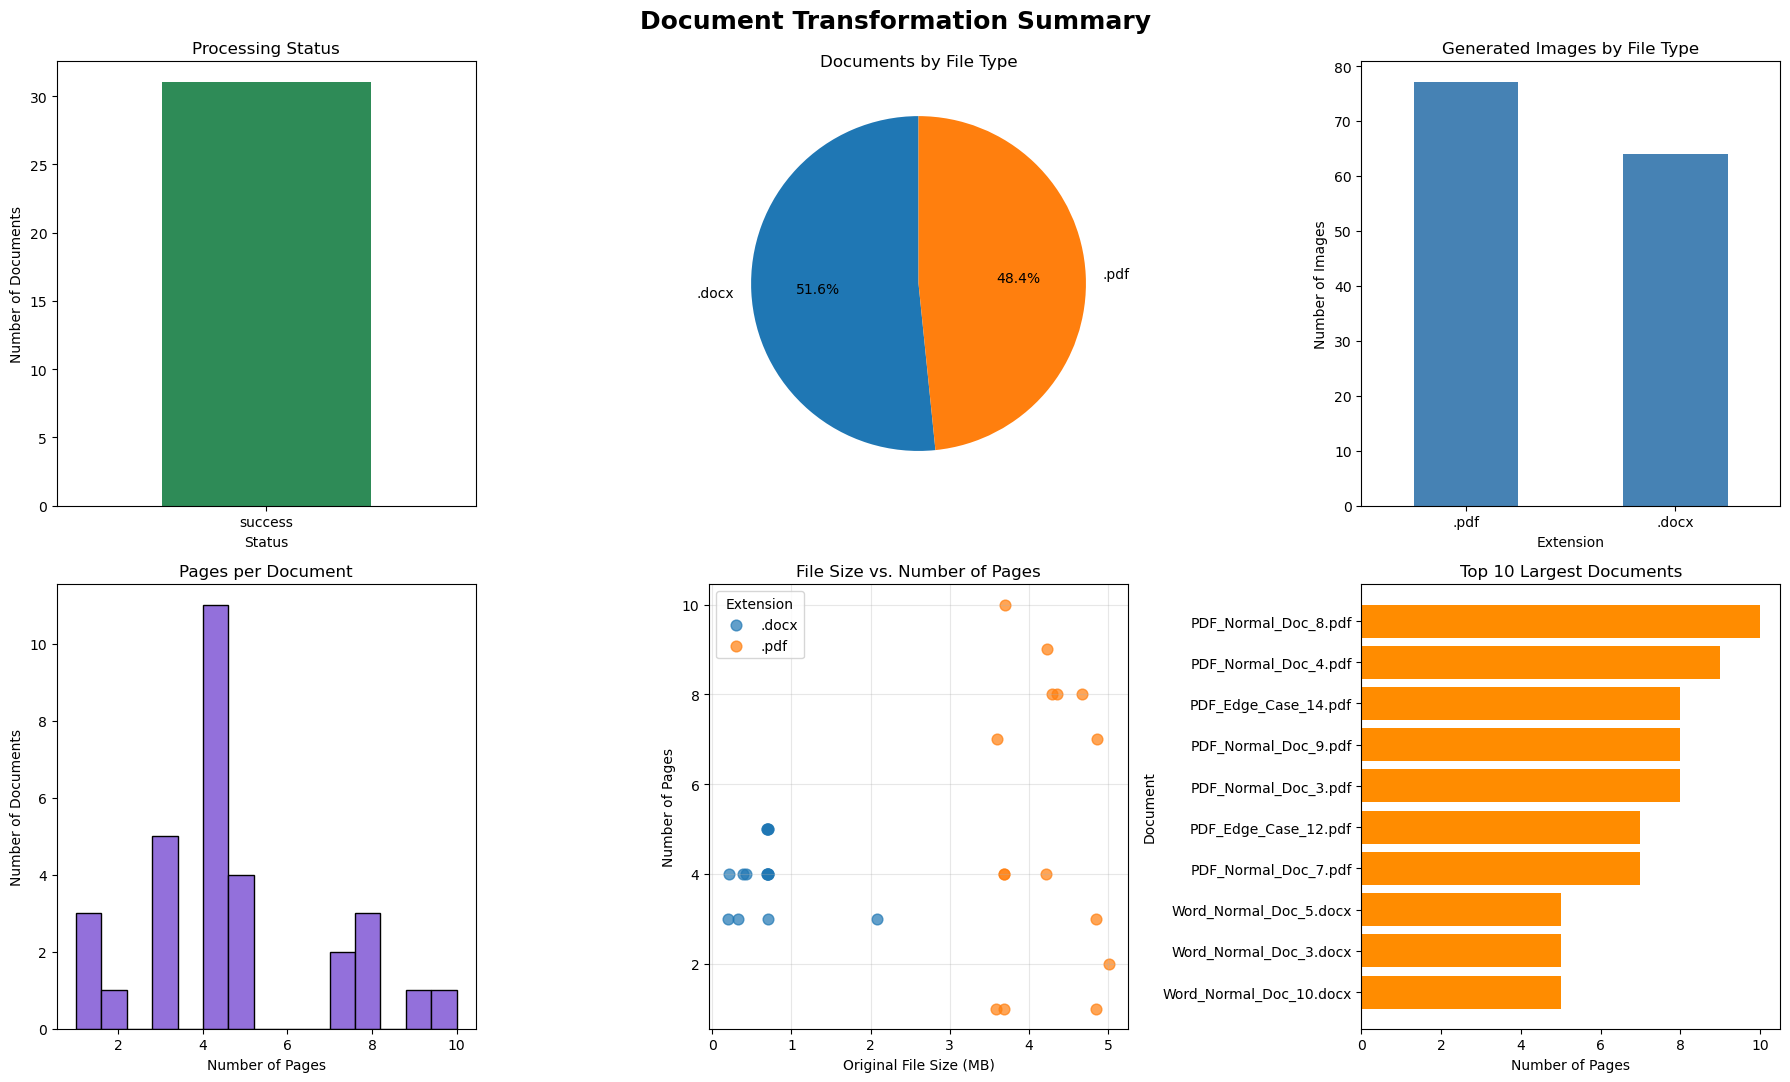

In [10]:
plot_df = documents_df.copy()
plot_df["page_count"] = pd.to_numeric(plot_df["page_count"], errors="coerce").fillna(0)
plot_df["size_mb"] = (pd.to_numeric(plot_df["size_bytes"], errors="coerce") / (1024 ** 2))
successful_df = plot_df[ plot_df["status"] == "success" ].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 1. Processing status
status_counts = plot_df["status"].value_counts()
status_counts.plot(
    kind="bar",
    ax=axes[0, 0],
    color=["seagreen", "tomato", "orange"],
)

axes[0, 0].set_title("Processing Status")
axes[0, 0].set_xlabel("Status")
axes[0, 0].set_ylabel("Number of Documents")
axes[0, 0].tick_params(axis="x", rotation=0)


# 2. Documents by extension
extension_counts = plot_df["extension"].value_counts()
extension_counts.plot(
    kind="pie",
    ax=axes[0, 1],
    autopct="%1.1f%%",
    startangle=90,
    ylabel="",
)

axes[0, 1].set_title("Documents by File Type")


# 3. Total generated pages by extension
pages_by_extension = successful_df.groupby("extension")["page_count"].sum().sort_values(ascending=False)
pages_by_extension.plot(
    kind="bar",
    ax=axes[0, 2],
    color="steelblue",
)

axes[0, 2].set_title("Generated Images by File Type")
axes[0, 2].set_xlabel("Extension")
axes[0, 2].set_ylabel("Number of Images")
axes[0, 2].tick_params(axis="x", rotation=0)


# 4. Page-count distribution
successful_df["page_count"].plot(
    kind="hist",
    bins=15,
    ax=axes[1, 0],
    color="mediumpurple",
    edgecolor="black",
)

axes[1, 0].set_title("Pages per Document")
axes[1, 0].set_xlabel("Number of Pages")
axes[1, 0].set_ylabel("Number of Documents")


# 5. File size compared with page count
for extension, group in successful_df.groupby("extension"):
    axes[1, 1].scatter(
        group["size_mb"],
        group["page_count"],
        label=extension,
        alpha=0.7,
        s=60
    )

axes[1, 1].set_title("File Size vs. Number of Pages")
axes[1, 1].set_xlabel("Original File Size (MB)")
axes[1, 1].set_ylabel("Number of Pages")
axes[1, 1].legend(title="Extension")
axes[1, 1].grid(alpha=0.3)


# 6. Ten documents with the most pages
top_documents = successful_df.nlargest(10, "page_count").sort_values("page_count")
axes[1, 2].barh(top_documents["filename"], top_documents["page_count"], color="darkorange")
axes[1, 2].set_title("Top 10 Largest Documents")
axes[1, 2].set_xlabel("Number of Pages")
axes[1, 2].set_ylabel("Document")


plt.suptitle("Document Transformation Summary", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

<div style="direction: rtl !important; text-align: right !important; font-family: inherit; background: #f7fafc; border: 1px solid #e1e8ed; border-right: 5px solid #3498db; border-radius: 12px; padding: 18px 22px;">
<div style="direction: rtl !important; text-align: right !important; font-weight: 700; color: #2471a3; margin-bottom: 5px;">ממצאים</div>
<div style="direction: rtl !important; text-align: right !important; line-height: 1.75; color: #2c3e50;">כל 31 המסמכים הומרו בהצלחה, ללא כשלים. המסמכים מתחלקים ל-51.6% קובצי DOCX ו-48.4% קובצי PDF. מספר התמונות שנוצרו מקובצי PDF גבוה ממספר התמונות שנוצרו מקובצי DOCX, אף שקובצי ה-DOCX מהווים את הרוב במאגר. מספר העמודים למסמך נע בין עמוד אחד לעשרה, כשהערך השכיח ביותר הוא ארבעה עמודים. בהשוואת גודל הקובץ המקורי למספר העמודים נצפים שני אשכולות נפרדים: קובצי DOCX מרוכזים מתחת למגה-בייט אחד, וקובצי PDF בטווח של שלושה עד חמישה מגה-בייט, בעוד ששתי הקבוצות מתפרשות על טווח דומה של מספר עמודים. עשרת המסמכים בעלי מספר העמודים הגבוה ביותר כוללים שבעה קובצי PDF ושלושה קובצי DOCX.</div>
</div>